# 📊 Analyse Antifraude OpenG2P

**Utilise les fichiers existants :**
- `ml/data/openg2p_scored.csv` (généré par train_openg2p.py)
- `ml/models/*.joblib` (modèles entraînés)

**Workflow :**
1. Générer dataset : `python ml/generate_dataset.py --n 10000`
2. Entraîner : `python train_openg2p.py`
3. Analyser : ce notebook

---

In [30]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import load
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, auc
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ Setup OK")

✅ Setup OK


In [32]:
# Charger le dataset scoré (généré par train_openg2p.py)
df = pd.read_csv("C:/Users/Mega Pc/Desktop/poc-v2/poc-v2/fraud-detection-engine/ml/data/openg2p_scored.csv")

print(f"📊 Dataset: {len(df)} lignes")
print(f"\nDistribution fraud:")
print(df['is_fraud'].value_counts())
print(f"\nTaux: {df['is_fraud'].mean():.2%}")

df.head()

📊 Dataset: 10000 lignes

Distribution fraud:
is_fraud
0    8800
1    1200
Name: count, dtype: int64

Taux: 12.00%


,age,income,income_per_person,household_size,nb_children,nb_elderly,has_disabled,single_head,nb_programs,pmt_score,...,dependency_ratio,risk_density,financial_stress,behavior_score,rule_score,graph_score,ml_score,anomaly_score,risk_score,risk_level
0,68,548.329422,109.67,5,2,0,False,True,2,0.627903,...,0.333333,0.333333,171.922646,2.00,0.0,0.000000,0.0000,0.131493,0.026299,low
1,63,755.224713,107.89,7,2,0,False,False,3,0.861204,...,0.250000,0.375000,123.840042,2.25,0.0,0.000000,0.0400,0.290156,0.072031,low
2,60,1707.708733,1707.71,1,0,0,False,False,1,0.619081,...,0.000000,0.500000,2714.611680,1.50,0.3,0.160756,0.0175,0.694275,0.266056,low
3,24,480.919492,120.23,4,1,0,False,False,3,0.647319,...,0.200000,0.600000,182.909784,2.25,0.3,0.160756,0.0325,0.172000,0.166851,low
4,56,1226.799677,408.93,3,0,0,False,False,3,0.835617,...,0.000000,0.750000,483.587741,2.25,0.0,0.000000,0.0150,0.144298,0.034110,low


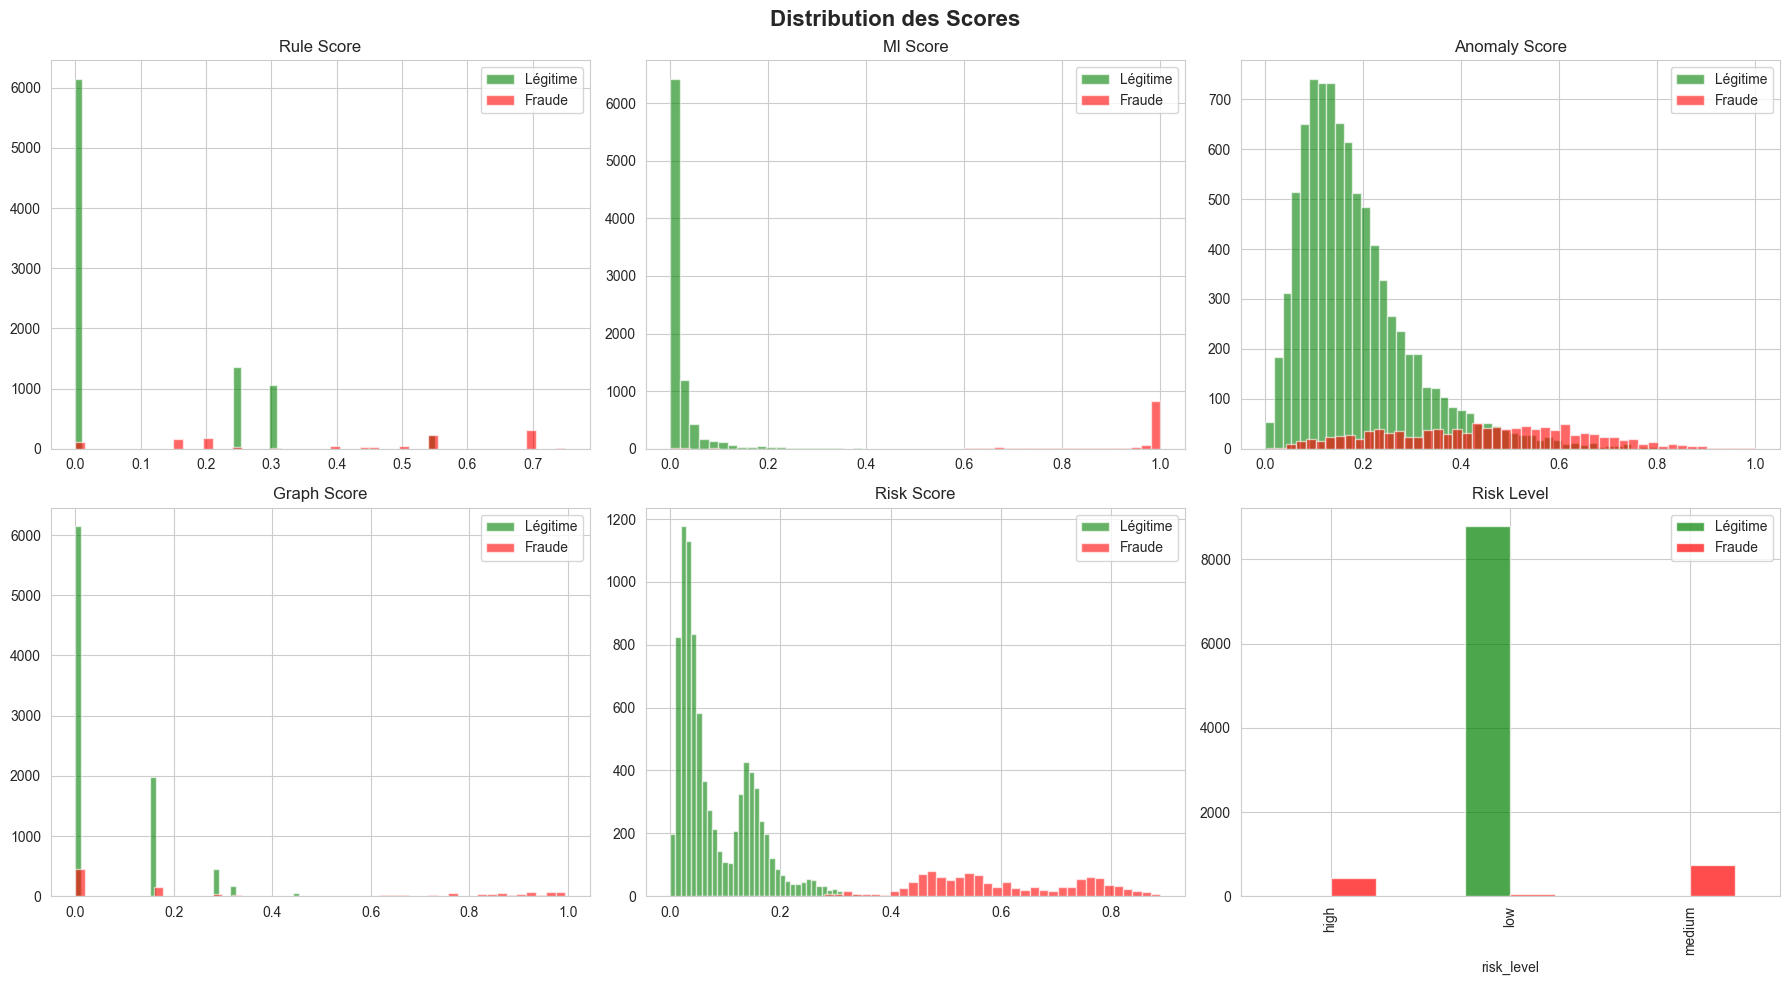

In [36]:
# Distribution des scores
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution des Scores', fontsize=16, fontweight='bold')
axes = axes.flatten()

scores = ['rule_score', 'ml_score', 'anomaly_score', 'graph_score', 'risk_score']

for idx, score in enumerate(scores):
    ax = axes[idx]
    df[df['is_fraud'] == 0][score].hist(bins=50, alpha=0.6, label='Légitime', ax=ax, color='green')
    df[df['is_fraud'] == 1][score].hist(bins=50, alpha=0.6, label='Fraude', ax=ax, color='red')
    ax.set_title(score.replace('_', ' ').title())
    ax.legend()

# Risk level
ax = axes[5]
df.groupby(['risk_level', 'is_fraud']).size().unstack(fill_value=0).plot(
    kind='bar', ax=ax, color=['green', 'red'], alpha=0.7)
ax.set_title('Risk Level')
ax.legend(['Légitime', 'Fraude'])

plt.tight_layout()
plt.savefig('../outputs/score_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

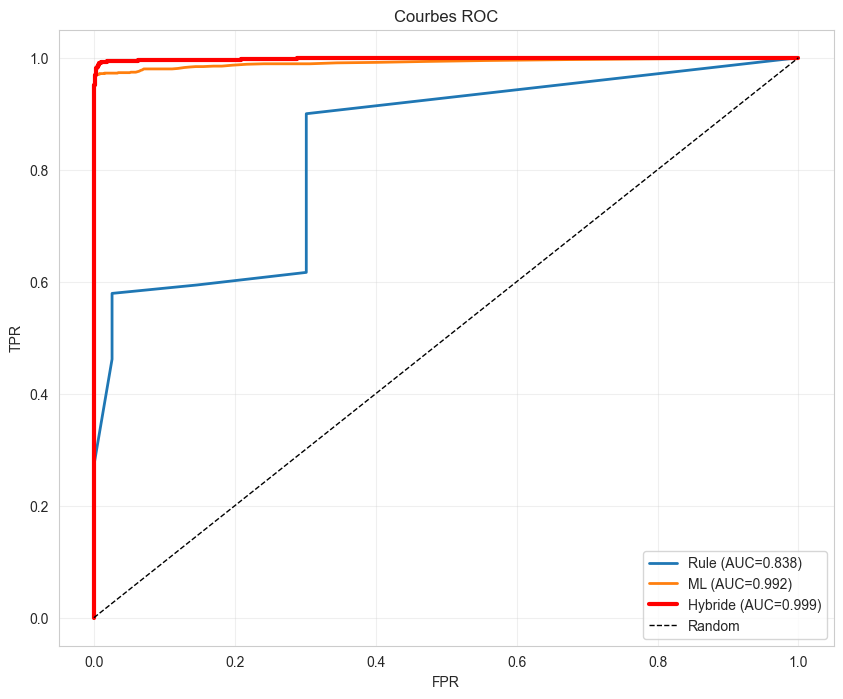


AUC Scores:
  Rule: 0.8377
  ML: 0.9917
  Hybride: 0.9986


In [38]:
# Courbes ROC
fpr_rule, tpr_rule, _ = roc_curve(df['is_fraud'], df['rule_score'])
fpr_ml, tpr_ml, _ = roc_curve(df['is_fraud'], df['ml_score'])
fpr_risk, tpr_risk, _ = roc_curve(df['is_fraud'], df['risk_score'])

auc_rule = roc_auc_score(df['is_fraud'], df['rule_score'])
auc_ml = roc_auc_score(df['is_fraud'], df['ml_score'])
auc_risk = roc_auc_score(df['is_fraud'], df['risk_score'])

plt.figure(figsize=(10, 8))
plt.plot(fpr_rule, tpr_rule, label=f'Rule (AUC={auc_rule:.3f})', linewidth=2)
plt.plot(fpr_ml, tpr_ml, label=f'ML (AUC={auc_ml:.3f})', linewidth=2)
plt.plot(fpr_risk, tpr_risk, label=f'Hybride (AUC={auc_risk:.3f})', linewidth=3, color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Courbes ROC')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../outputs/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nAUC Scores:")
print(f"  Rule: {auc_rule:.4f}")
print(f"  ML: {auc_ml:.4f}")
print(f"  Hybride: {auc_risk:.4f}")

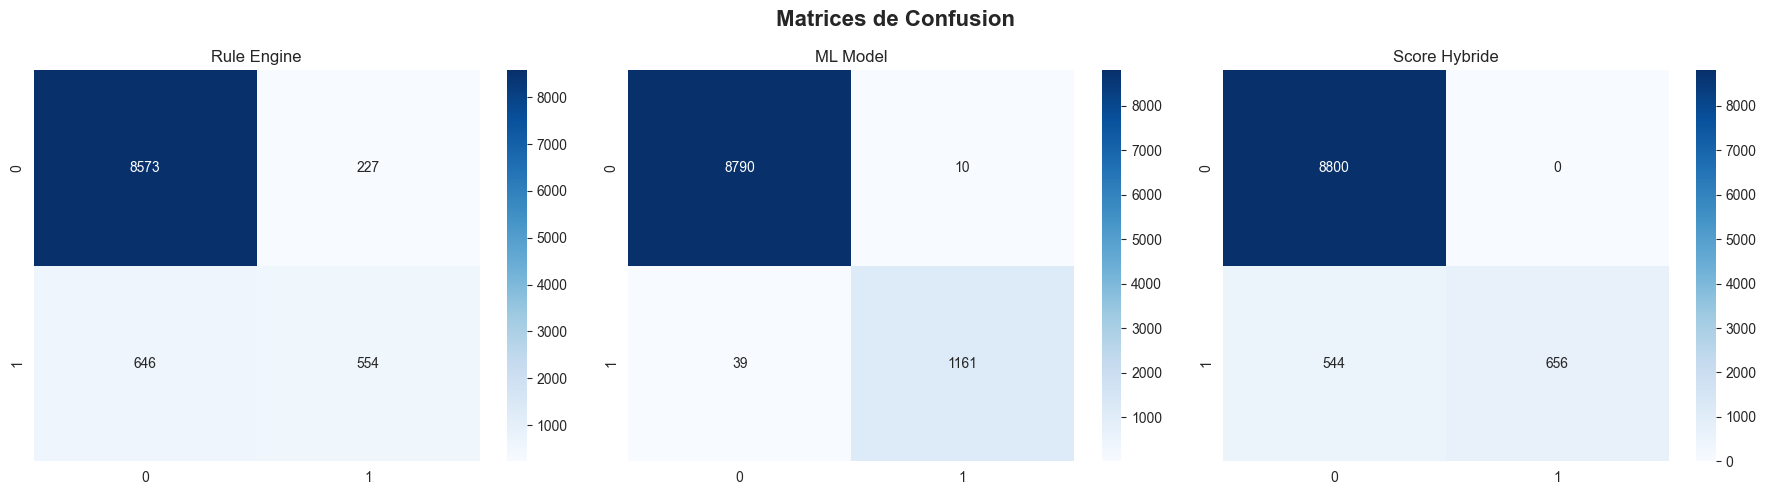

In [42]:
# Matrices de confusion
threshold = 0.55
pred_rule = (df['rule_score'] >= threshold).astype(int)
pred_ml = (df['ml_score'] >= threshold).astype(int)
pred_risk = (df['risk_score'] >= threshold).astype(int)

cm_rule = confusion_matrix(df['is_fraud'], pred_rule)
cm_ml = confusion_matrix(df['is_fraud'], pred_ml)
cm_risk = confusion_matrix(df['is_fraud'], pred_risk)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusion', fontsize=16, fontweight='bold')

for idx, (cm, title) in enumerate([
    (cm_rule, 'Rule Engine'),
    (cm_ml, 'ML Model'),
    (cm_risk, 'Score Hybride')
]):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

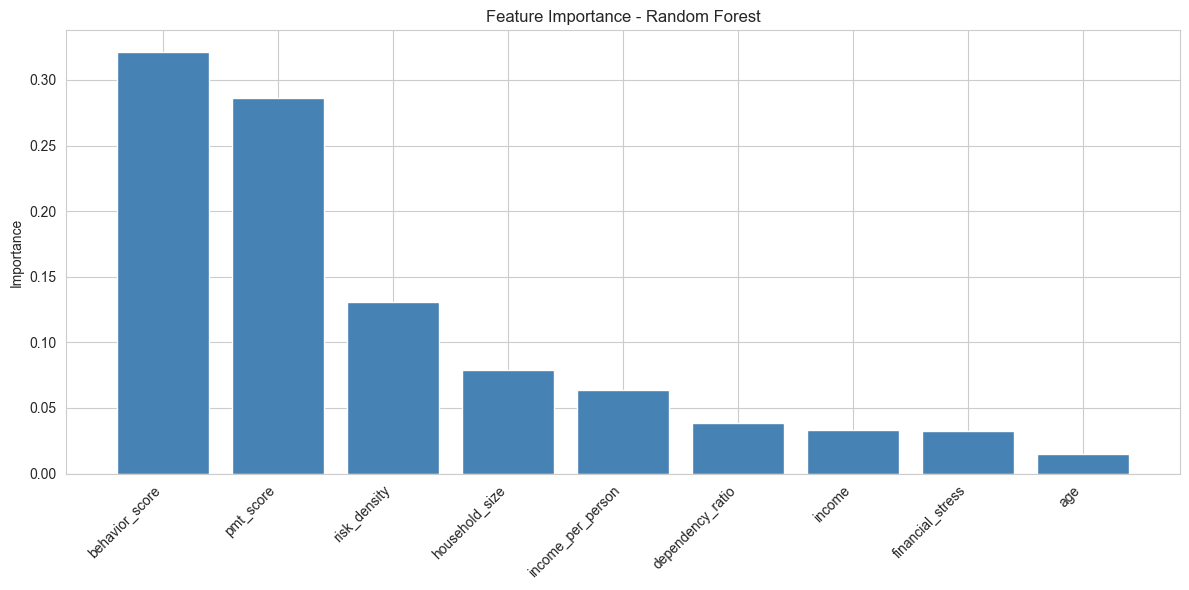


Top 5 Features:
  1. behavior_score: 0.3217
  2. pmt_score: 0.2861
  3. risk_density: 0.1304
  4. household_size: 0.0789
  5. income_per_person: 0.0634


In [46]:
# Feature Importance
rf = load("../models/random_forest.joblib")

feature_names = ['age', 'income', 'household_size', 'dependency_ratio', 
                 'income_per_person', 'pmt_score', 'risk_density', 
                 'financial_stress', 'behavior_score']

importances = rf.named_steps['clf'].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[indices], color='steelblue')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 5 Features:")
for i in range(5):
    print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

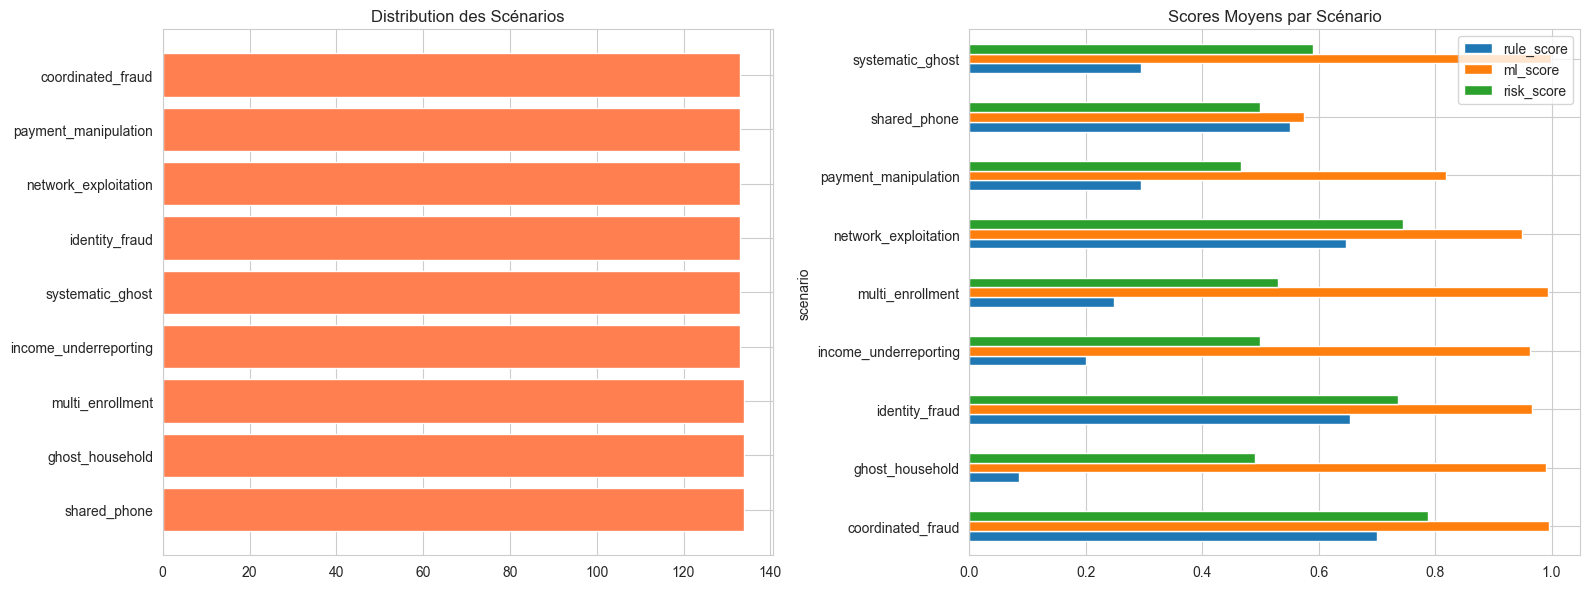

In [48]:
# Analyse des scénarios
if 'scenario' in df.columns:
    fraud_data = df[df['is_fraud'] == 1]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Distribution
    scenario_counts = fraud_data['scenario'].value_counts()
    axes[0].barh(scenario_counts.index, scenario_counts.values, color='coral')
    axes[0].set_title('Distribution des Scénarios')
    
    # Scores moyens
    scenario_scores = fraud_data.groupby('scenario')[['rule_score', 'ml_score', 'risk_score']].mean()
    scenario_scores.plot(kind='barh', ax=axes[1])
    axes[1].set_title('Scores Moyens par Scénario')
    
    plt.tight_layout()
    plt.savefig('../outputs/scenarios_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

In [50]:
# Tableau récapitulatif
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = []
for name, predictions, scores in [
    ('Rule Engine', pred_rule, df['rule_score']),
    ('ML Model', pred_ml, df['ml_score']),
    ('Score Hybride', pred_risk, df['risk_score'])
]:
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(df['is_fraud'], predictions),
        'Precision': precision_score(df['is_fraud'], predictions),
        'Recall': recall_score(df['is_fraud'], predictions),
        'F1-Score': f1_score(df['is_fraud'], predictions),
        'AUC': roc_auc_score(df['is_fraud'], scores)
    })

results_df = pd.DataFrame(results).round(4)
print("\n" + "="*70)
print("PERFORMANCES COMPARÉES")
print("="*70)
print(results_df.to_string(index=False))

results_df.to_csv('../outputs/performance_summary.csv', index=False)
print("\n✅ Sauvegardé: ml/outputs/performance_summary.csv")


PERFORMANCES COMPARÉES
       Modèle  Accuracy  Precision  Recall  F1-Score    AUC
  Rule Engine    0.9127     0.7093  0.4617    0.5593 0.8377
     ML Model    0.9951     0.9915  0.9675    0.9793 0.9917
Score Hybride    0.9456     1.0000  0.5467    0.7069 0.9986

✅ Sauvegardé: ml/outputs/performance_summary.csv
